In [1]:
import sys
import json
import pathlib

import pandas as pd
import matplotlib.pyplot as plt

# Locate the repository root (the directory that contains simulation_engine) so the
# notebook runs regardless of the directory Jupyter was launched from.
repository_path = pathlib.Path.cwd()
while not (repository_path / "simulation_engine").is_dir() and repository_path != repository_path.parent:
    repository_path = repository_path.parent
machine_learning_path = repository_path / "notebooks" / "machine_learning"
for path_entry in (str(repository_path), str(machine_learning_path)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)

import rl_helpers.rl_plots as rl_plots

data_rl_path = repository_path / "data" / "rl"

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Reinforcement learning agents for *Volcano Rush*

*A tabular Q-learning and SARSA study of two cooperative board-game decisions.*

## Abstract

*Volcano Rush* is a cooperative survival board game for 6-8 players, implemented as a deterministic,
seedable Python simulation engine. Its agents currently play through hand-written heuristics. This
project replaces two of those heuristics - which mission to attempt and who to staff on it - with
tabular reinforcement learning agents trained by self-play, and asks whether a blank-slate learner
can match or beat the hand-tuned rules. We frame each decision as a semi-Markov decision process
over a compact, hand-designed state abstraction, train both off-policy (Q-learning) and on-policy
(SARSA) agents, and evaluate them against the baseline on held-out seeds with paired statistics
(Wilson intervals and McNemar's test). The finding splits by decision: learning the mission choice
significantly beats the hand-tuned heuristic at every player count, while learning the
participant-staffing decision underperforms its already well-tuned heuristic; learning both jointly
partly cancels the two effects.

## Introduction

Board-game balance is usually studied by simulating fixed strategies. A complementary question is
whether a *learning* agent, given no strategy at all, will arrive at good play - and what that
reveals about the game. If a learner trained only on the win/loss signal converges to the same moves
a designer hand-coded, that is evidence the heuristics are well chosen; where it diverges, it points
at situations the heuristics handle suboptimally.

We study the two most consequential per-round decisions in *Volcano Rush*: the choice of mission and
the choice of participants. We deliberately keep everything else (the rule-based shuffle decision,
the volcano dynamics) fixed so the learning problem is isolated and the comparison is clean.

**Problem.** Learn a policy for the mission and participant decisions that maximises the team's
probability of escaping the island before the volcano erupts.

**Significance.** The result is a worked, reproducible example of casting a stochastic cooperative
game as an MDP, designing a tractable state abstraction, and validating a learned policy with proper
paired statistics rather than eyeballed averages.

## The game and the engine

*Volcano Rush* strands 6-8 players on a volcanic island; they must build a boat before the volcano
erupts.

- **Resources.** Each player holds a hand of wood, stone, and rope cards.
- **Missions.** Thirteen missions span four types: fire, food, shelter, and boat. Each round three
  are active; attempting one requires each participant to pay its per-player cost (after their
  character's discount). Boat missions, when completed, add a boat part.
- **Characters.** Six roles (Builder, Fire Starter, Craftsman, Cook, Gatherer, Sailor) give passive
  or active abilities; at 7-8 players some non-Craftsman roles repeat.
- **Complications and the volcano.** A complication card drawn during a mission can raise its cost
  or damage a shared tool. After most rounds a volcano card is turned; these apply pressure, and the
  Eruption card ends the game.
- **Win / loss.** The team wins by building all required boat parts (3 at 6 players, 4 at 7, 5 at 8)
  and loses if Eruption is drawn first or 200 rounds elapse.

The engine (`simulation_engine/`) resolves all of this deterministically given a seed, and exposes
`run_game` / `run_scenario`. A small, backward-compatible hook lets a learned policy be injected for
the mission and participant decisions; with no policy supplied, play is bit-identical to the
hand-written agents.

## Related work

The methods are textbook tabular reinforcement learning (Sutton and Barto, *Reinforcement Learning:
An Introduction*). We use **Q-learning** (Watkins), an off-policy temporal-difference control method
that bootstraps on the greedy next action, and **SARSA**, its on-policy counterpart that bootstraps
on the action actually taken. Because the agent acts only on some rounds, the formulation is a
**semi-Markov decision process**, where a decision transitions to the next decision of the same kind
and accumulates the intervening reward. Win-rate uncertainty uses the **Wilson score interval**, and
the paired policy comparison uses **McNemar's test** for matched binary outcomes.

## Data

The data are generated by experiment: self-play rollouts of the engine. Each training episode is one
seeded game; the game's stochastic dynamics are seeded from the global random stream exactly as the
existing `run_scenario` does, while the agent's exploration draws from a separate private random
stream so the two never interfere and full runs are reproducible. Evaluation uses a disjoint,
held-out seed range. All trained tables and evaluation summaries are persisted under `data/rl/`.

## Methods

**Two parallel semi-MDPs.** The mission decision and the participant decision are learned by separate
agents with separate Q-tables that share one reward stream but never bootstrap on each other.

**State abstraction.** The mission state is a 7-feature key (4608 possible values) capturing volcano
urgency, boat progress, a Panic flag, the status of the next-needed boat part, boat affordability,
the non-boat categories on offer, and the active player's own affordability. The participant state
is a 6-feature per-candidate key (144 values) capturing affordability, ability relevance, the
Craftsman-repair situation, score lead, whether the mission is a boat, and whether the candidate is
the active player. (Notebook 2.)

**Action spaces.** Mission actions are five stationary semantic categories (next-needed boat, other
boat, fire, food, shelter) rather than positional slots. Participant actions are a per-candidate
include/exclude, decoded by ranking candidates on the learned include-margin and taking the top
`players_count`.

**Reward.** Sparse and terminal: $+1$ for a win, $-1$ for a loss, with small shaping ($+0.1$ per
boat part built, a $-0.002$ per-decision step penalty) to ease credit assignment.

**Update.** $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma B - Q(s,a)]$ with $B = \max_{a'} Q(s',a')$
for Q-learning and $B = Q(s', a'_{\text{taken}})$ for SARSA; $\gamma = 0.95$, and $\alpha,\epsilon$
decay linearly. (Notebook 3.)

## Experiments

1. [Environment and MDP](experiments/1_environment_and_mdp.ipynb) - the engine hook and the
   decision process.
2. [State and action design](experiments/2_state_and_action_design.ipynb) - the abstractions and
   their reachable coverage.
3. [Training and convergence](experiments/3_training_qlearning_vs_sarsa.ipynb) - Q-learning vs SARSA
   learning curves.
4. [Evaluation against the baseline](experiments/4_evaluation_vs_baseline.ipynb) - paired win-rate
   comparison with Wilson intervals and McNemar tests.
5. [What did the agent learn?](experiments/5_policy_inspection.ipynb) - reading the Q-tables.

The matrix spans player counts {6, 7, 8}, both update rules, and three ablations: **mission-only**
(learn the mission, baseline staffing), **participant-only** (baseline mission, learn staffing), and
**joint** (learn both).

## Results summary

The table below loads the precomputed evaluation matrix and reports, for each ablation, the
baseline and learned (Q-learning) win rates averaged over player counts, with the held-out game
count. The plot underneath is the headline joint-agent comparison by player count.

,ablation,mean_baseline_win_rate,mean_learned_win_rate
0,mission_only,0.356,0.420
1,participant_only,0.356,0.315
2,joint,0.356,0.371


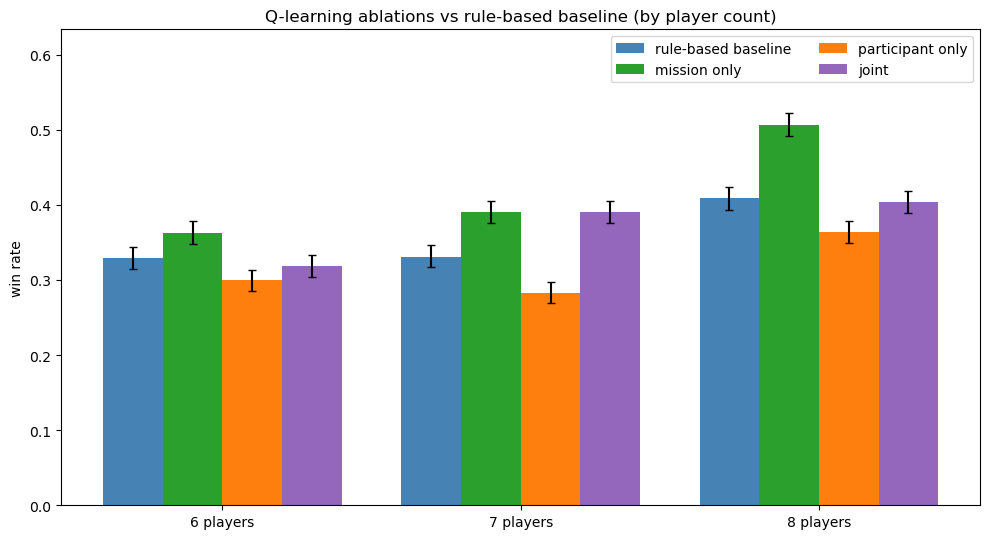

In [2]:
manifest = json.loads((data_rl_path / 'manifest.json').read_text())

def load_eval(ablation, update_rule, player_count):
    return json.loads((data_rl_path / f'eval_{ablation}_{update_rule}_pc{player_count}.json').read_text())

rows = []
for ablation in manifest['ablations']:
    baseline_rates = []
    learned_rates = []
    for player_count in manifest['player_counts']:
        summary = load_eval(ablation, 'q_learning', player_count)
        baseline_rates.append(summary['baseline_win_rate'])
        learned_rates.append(summary['rl_win_rate'])
    rows.append({
        'ablation': ablation,
        'mean_baseline_win_rate': round(sum(baseline_rates) / len(baseline_rates), 3),
        'mean_learned_win_rate': round(sum(learned_rates) / len(learned_rates), 3),
    })
display(pd.DataFrame(rows))

summaries = {
    (ablation, player_count): load_eval(ablation, 'q_learning', player_count)
    for ablation in manifest['ablations']
    for player_count in manifest['player_counts']
}
figure = rl_plots.plot_ablation_comparison(
    summaries,
    player_counts = manifest['player_counts'],
    ablations = manifest['ablations'],
    title = 'Q-learning ablations vs rule-based baseline (by player count)',
)
plt.show()

## Discussion

The result splits cleanly by decision. **Mission selection is where reinforcement learning helps**: a
blank-slate agent trained only on win/loss reward beats the hand-written `vote_for_mission` heuristic
at every player count, by 3 to 11 win-rate points (McNemar $p < 0.001$), with the largest gains at 8
players where the boat is longest. Inspecting the policy (notebook 5) shows why: the learner commits
to the next-needed boat part earlier and more consistently than the baseline, which only prioritises
boats once the volcano deck is short. **Participant selection is where it does not help**: the shipped
scoring heuristic is well tuned, and the coarser learned include/exclude ranking trails it by 3 to 10
points. Learning both at once nets a small positive change on average, as the mission gains are partly
offset by the weaker staffing. Q-learning and SARSA behave almost identically once exploration has
decayed. The takeaway for the game's design: the mission heuristic has exploitable slack that a
learner finds, whereas the staffing heuristic is already close to what a tabular learner can recover.

## Limitations

- **Tabular ceiling.** A lossy hand-designed abstraction caps how much the agent can distinguish; a
  function approximator could use the raw state but loses interpretability.
- **Joint non-stationarity.** When both decisions learn at once, each is part of the other's
  environment; the mission-only and participant-only ablations isolate each against a stable
  baseline for that reason.
- **Strong baseline.** The heuristic leaves little headroom on win rate, so the comparison is more
  about matching than beating it.
- **Shaping sensitivity.** The small shaping rewards help credit assignment but are a modelling
  choice; the terminal win/loss signal remains dominant.

## Further work

- Learn the shuffle decision too, for a fully learned agent.
- Share one Q-table across player counts, or add a count feature, to test transfer.
- Replace the tabular table with linear or neural function approximation over richer features.
- Search reward-shaping and schedule hyperparameters, and probe the calm (non-urgent) regime where
  the baseline is least tuned.

## References

- R. S. Sutton and A. G. Barto. *Reinforcement Learning: An Introduction*, 2nd ed. MIT Press, 2018.
- The *Volcano Rush* simulation engine and rulebook in this repository (`simulation_engine/`, `docs/`).

## Appendix

All reusable code lives in the tested package `simulation_engine/rl/` (state encoders, action
spaces, the tabular agent, the trajectory recorder, training, evaluation, and persistence). The
experiment matrix is driven by `notebooks/machine_learning/rl_helpers/experiment.py`, and the trained
tables and evaluation summaries are stored under `data/rl/`. Every component is covered by unit
tests under `tests/` (run `pytest tests/ -v`), including a gate that the engine hook leaves default
play bit-identical.